Quick environment setup (run once in a terminal / notebook cell)

In [1]:
!pip install pandas numpy matplotlib scikit-learn joblib xgboost

Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

Data Fetching

In [3]:
df = pd.read_csv(r"Water-Dataset.csv")
df.head()

,E_coli,Total_Coliforms,Enterococci,Turbidity,Residual_Chlorine,Nitrate,Disease_Risk
0,334.412543,861.494648,346.053783,9.045120,1.177617,20.831581,Cholera
1,175.355658,826.920085,255.450290,9.459154,2.793374,3.188241,Dysentery
2,446.552869,831.486917,6.850681,15.567454,0.273966,46.229898,Cholera
3,139.017653,864.154802,416.576579,6.132452,0.695131,26.829010,Hepatitis
4,26.243522,1531.755883,250.237757,6.889551,1.248436,27.384346,Diarrhea


Features & Split

In [4]:
# Select features and label
features = ["E_coli","Total_Coliforms","Enterococci","Turbidity","Residual_Chlorine","Nitrate"]
label = "Disease_Risk"

X = df[features]
le = LabelEncoder()
y = le.fit_transform(df[label])
class_names = le.classes_

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

Class Distribution (Plot 1)

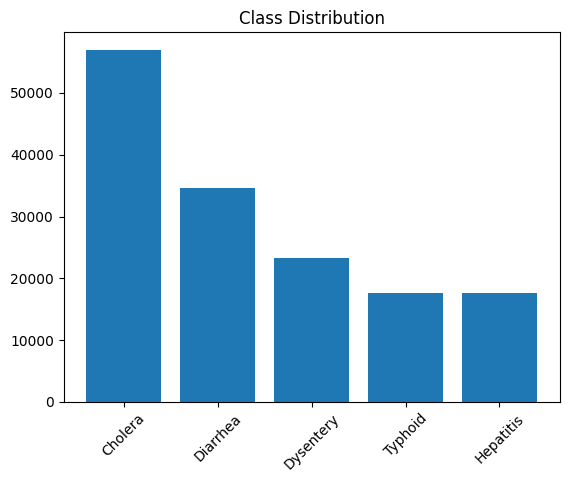

In [5]:
counts = df[label].value_counts()
plt.bar(counts.index, counts.values)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

Random Forest

In [6]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("RandomForest Accuracy:", round(accuracy_score(y_test, y_pred_rf)*100, 2), "%")
print(classification_report(y_test, y_pred_rf, target_names=class_names, zero_division=0))

RandomForest Accuracy: 67.83 %
              precision    recall  f1-score   support

     Cholera       0.68      0.89      0.77     11392
    Diarrhea       0.69      0.74      0.71      6907
   Dysentery       0.68      0.54      0.60      4651
   Hepatitis       0.67      0.36      0.47      3517
     Typhoid       0.67      0.36      0.47      3533

    accuracy                           0.68     30000
   macro avg       0.68      0.58      0.60     30000
weighted avg       0.68      0.68      0.66     30000



XGBoost (or fallback)

In [7]:
try:
    from xgboost import XGBClassifier
    model = XGBClassifier(
        n_estimators=300,
        eval_metric="mlogloss",
        random_state=42
    )
    name = "XGBoost"
except:
    from sklearn.ensemble import GradientBoostingClassifier
    model = GradientBoostingClassifier(random_state=42)
    name = "GradientBoosting (fallback)"

model.fit(X_train, y_train)
y_pred_xgb = model.predict(X_test)

print(name, "Accuracy:", round(accuracy_score(y_test, y_pred_xgb)*100, 2), "%")
print(classification_report(y_test, y_pred_xgb, target_names=class_names, zero_division=0))

XGBoost Accuracy: 67.39 %
              precision    recall  f1-score   support

     Cholera       0.68      0.89      0.77     11392
    Diarrhea       0.68      0.74      0.71      6907
   Dysentery       0.67      0.53      0.59      4651
   Hepatitis       0.65      0.36      0.47      3517
     Typhoid       0.66      0.36      0.46      3533

    accuracy                           0.67     30000
   macro avg       0.67      0.58      0.60     30000
weighted avg       0.67      0.67      0.66     30000



Confusion Matrix (Plot 2)

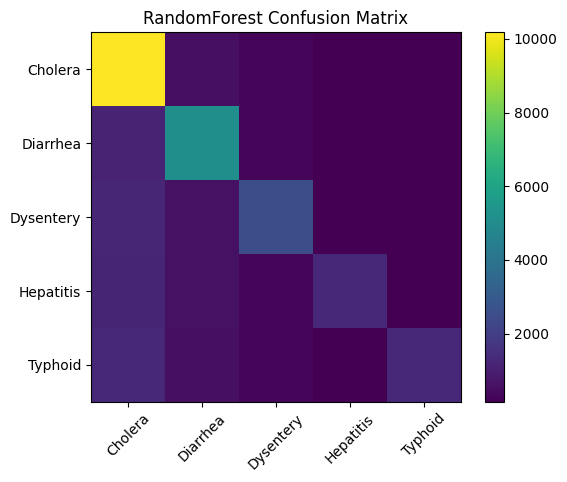

In [8]:
cm = confusion_matrix(y_test, y_pred_rf)
plt.imshow(cm)
plt.title("RandomForest Confusion Matrix")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.show()

Input & Prediction

In [10]:
# Example input (change values as you like)
sample_input = pd.DataFrame([{
    "E_coli": 250,
    "Total_Coliforms": 90,
    "Enterococci": 125,
    "Turbidity": 8,
    "Residual_Chlorine": 0.2,
    "Nitrate": 35
}])

print("Sample Input:")
print(sample_input)

# Predict using RandomForest
pred_class = rf.predict(sample_input)[0]
pred_proba = rf.predict_proba(sample_input)[0]

print("\nPredicted Disease (RandomForest):", le.inverse_transform([pred_class])[0])

# Show probabilities for each disease
for disease, prob in zip(class_names, pred_proba):
    print(f"{disease}: {prob*100:.2f}%")

Sample Input:
   E_coli  Total_Coliforms  Enterococci  Turbidity  Residual_Chlorine  Nitrate
0     250               90          125          8                0.2       35

Predicted Disease (RandomForest): Typhoid
Cholera: 24.00%
Diarrhea: 9.00%
Dysentery: 15.00%
Hepatitis: 16.00%
Typhoid: 36.00%
